# 분류 실습 — Pima Indians Diabetes

이번엔 **Pima Indians Diabetes** 데이터로 당뇨병 여부를 예측하는 분류 문제를 풀어보겠습니다.

미국 애리조나 주 Pima 인디언 부족 여성들을 대상으로 한 건강 검진 데이터이며, 신체 지표로부터 **당뇨병 여부(`Outcome`)를 예측**하는 것이 목표입니다. seaborn에는 내장되어 있지 않아서, 공개된 CSV를 URL로 바로 불러오겠습니다.

### 데이터 기본 정보

| 컬럼 | 뜻 |
|---|---|
| `Pregnancies` | 임신 횟수 |
| `Glucose` | 경구 포도당 부하 검사 2시간 후 혈장 포도당 농도 |
| `BloodPressure` | 이완기 혈압 (mm Hg) |
| `SkinThickness` | 삼두근 피부 주름 두께 (mm) |
| `Insulin` | 혈청 인슐린 수치 (2시간, mu U/ml) |
| `BMI` | 체질량지수 |
| `DiabetesPedigreeFunction` | 당뇨병 가족력 지수 |
| `Age` | 나이 |
| `Outcome` | **당뇨병 여부 (정답, 1=당뇨, 0=정상)** |

가장 가벼운 모델인 **Logistic Regression**으로 우선 베이스라인을 잡고, **5-Fold 교차검증**으로 성능을 확인해보겠습니다.

## 1. 데이터 불러오기 & 기본 정보

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print(df.shape)
df.info()

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


768개 행, 9개 컬럼(8개 특성 + `Outcome`)이 있고, 전부 수치형(int64/float64)입니다.

`Non-Null Count`가 전부 768로 동일한 것을 보면 결측치는 없어 보입니다. 아래에서 한 번 더 확인해보겠습니다.

## 2. 결측치 확인

In [3]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

`isna()` 기준으로는 결측치가 0개입니다. 말씀하신 대로 바로 학습을 진행해도 되는 상태처럼 보이네요.

다만 이 데이터셋은 유명한 함정이 하나 있습니다. `Glucose`(혈당), `BloodPressure`(혈압), `SkinThickness`(피부 두께), `Insulin`(인슐린), `BMI`(체질량지수)는 살아있는 사람이라면 **생리학적으로 0이 나올 수 없는 값**입니다. 즉 결측치를 `NaN`이 아니라 **0으로 표시해둔 경우**일 가능성이 높습니다. 한 번 확인해보겠습니다.

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = df[zero_cols].eq(0).sum()
zero_ratio = (zero_counts / len(df) * 100).round(1)

pd.DataFrame({'0값 개수': zero_counts, '비율(%)': zero_ratio})

,0값 개수,비율(%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


`Insulin`은 절반 가까이(약 49%), `SkinThickness`는 약 30%가 0으로 채워져 있습니다. 이 정도면 우연이라기보단 **결측치를 0으로 대체해서 기록한 것**으로 보는 게 맞습니다.

이번 실습에서는 우선 말씀하신 대로 **원본 그대로(0을 유효한 값으로 취급)** 베이스라인을 잡아보고, 이 값을 어떻게 처리할지는 다음 단계에서 다뤄보겠습니다. (`isna()`로는 안 잡히는 결측치가 있다는 점만 기억해두면 좋을 것 같습니다.)

## 3. 타겟(Outcome) 분포 확인

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


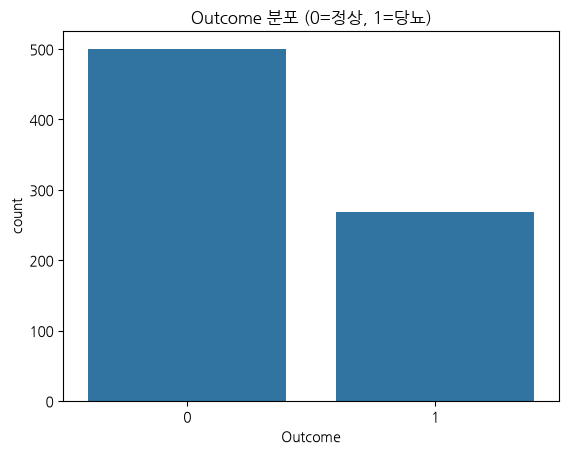

In [5]:
print(df['Outcome'].value_counts())
print((df['Outcome'].value_counts(normalize=True) * 100).round(1))

sns.countplot(data=df, x='Outcome')
plt.title('Outcome 분포 (0=정상, 1=당뇨)')
plt.show()

정상(0)이 500명(65.1%), 당뇨(1)이 268명(34.9%)으로 **완전히 균형 잡힌 데이터는 아닙니다.** 이런 경우 정확도(accuracy)만 보면 실제 성능을 오해하기 쉬워서, 이후 평가에서는 precision/recall/f1/AUC도 함께 확인하겠습니다.

## 4. 베이스라인 모델 — Logistic Regression (5-Fold CV)

가장 가벼운 모델인 Logistic Regression으로 베이스라인 성능을 잡아보겠습니다. 별도의 스케일링이나 결측치 처리 없이 **원본 데이터 그대로** 학습합니다.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

X = df.drop(columns=['Outcome'])
y = df['Outcome']

model = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

summary = pd.DataFrame({
    metric: [*np.round(cv_results[f'test_{metric}'], 3), round(cv_results[f'test_{metric}'].mean(), 3)]
    for metric in scoring
}, index=[f'fold{i+1}' for i in range(5)] + ['평균'])

summary

,accuracy,precision,recall,f1,roc_auc
fold1,0.779,0.750,0.556,0.638,0.816
fold2,0.779,0.763,0.537,0.630,0.868
fold3,0.786,0.769,0.556,0.645,0.844
fold4,0.765,0.707,0.547,0.617,0.807
fold5,0.745,0.630,0.642,0.636,0.816
평균,0.771,0.724,0.567,0.633,0.830


## 5. 결과 해석

- **Accuracy 평균 약 77.1%**: 단순히 '전부 정상(0)'으로만 찍어도 65.1%가 나오는 데이터이므로, 77%는 의미 있는 개선입니다.
- **ROC-AUC 평균 약 0.83**: 클래스 분포와 무관하게 두 그룹을 잘 구분해내는 편입니다.
- **Precision 약 72.4% vs Recall 약 56.7%**: 모델이 '당뇨'라고 예측하면 꽤 믿을 만하지만(precision), 실제 당뇨 환자의 **약 43%를 놓치고 있습니다**(recall이 낮음). 의료 데이터에서는 이 재현율(recall)이 특히 중요한데, 지금 베이스라인은 이 부분이 약점입니다.
- Fold 간 편차(std)가 크지 않아 (accuracy std ≈ 0.015) 성능이 특정 fold에 몰린 결과는 아닙니다.

**다음 단계로 시도해볼 만한 것들:**
1. 2절에서 확인한 **0으로 위장된 결측치**(Insulin, SkinThickness 등)를 중앙값 등으로 대체
2. 스케일링(`StandardScaler`) 적용 — Logistic Regression은 스케일에 민감
3. Recall을 끌어올리기 위한 `class_weight='balanced'` 또는 임계값 조정
4. 트리 기반 모델(RandomForest, GradientBoosting) 등과 성능 비교